# <img src="assets/logo_infnetv1.png" alt="Infnet logo" height="45"/> Projeto de Disciplina - Processamento de linguagem natural


### Aluno: 

- Lauro Barbosa <a href="https://github.com/LMRocha/D5_fundamentos_ml_scikitlearning"><img src="https://img.shields.io/badge/Github-151b23?style=flat-square&logo=github" alt="github_logo" height="20"/></a>


### Descrição do projeto:
O dataset utiliza de 2225 artigos da BBC categorizadas  business, entertainment, politics, sport or tech

## Importação as bibliotecas

In [90]:
import matplotlib.pyplot as plt
import numpy as np
import re
from dotenv import load_dotenv
import os
import pandas as pd
from kaggle.api.kaggle_api_extended import KaggleApi
import seaborn as sns
import warnings
import nltk
import spacy
import csv
import string
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from wordcloud import WordCloud
from collections import Counter

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

warnings.filterwarnings('ignore')
load_dotenv()
SEED=42

## Geração dos diretórios e download do dataset

In [91]:
# Inicializar a API do Kaggle
api = KaggleApi()
api.authenticate()

# Criar o diretório se não existir
data_path = 'data'
os.makedirs(data_path, exist_ok=True)

# Baixar os dados do Kaggle
api.dataset_download_files('hgultekin/bbcnewsarchive', path=data_path, unzip=True)

Dataset URL: https://www.kaggle.com/datasets/hgultekin/bbcnewsarchive


## Declaração de funções

### Funções de preparação de texto

In [103]:
def tokenize(text):
    return text.split()

def normalize(text):   
    return text.lower()

def clean_text(text):
    return re.sub(r'[^a-z\s]', '', text)

def lemmatize(tokens):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(t) for t in tokens]

def stemmize(tokens):
    stemmizer = PorterStemmer();
    return [stemmizer.stem(t) for t in tokens]

def apply_pos_tagging(text):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)
    filtered_words = [
        token.lemma_
        for token in doc
            if token.pos_ in ['NOUN', 'VERB', 'ADJ']
            and not token.is_stop
    ]

    return " ".join(filtered_words)

def preprocess_text(text, is_lemmatize: bool, is_stemmize: bool, is_pos_tagging: bool):
    text = normalize(text)
    text = clean_text(text)
    stop_words = set(stopwords.words('english'))
    tokens = tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    
    if is_lemmatize:
        tokens = lemmatize(tokens)
        return ' '.join(tokens)
    elif is_stemmize:
        tokens = stemmize(tokens)
        return ' '.join(tokens)
    elif is_pos_tagging:
        apply_pos_tagging(text)

def plot_word_cloud(processed_text):
    text = " ".join(processed_text)
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

def plot_bar_frequencia(processed_text):
    all_words = " ".join(processed_text).split()
    word_freq = Counter(all_words)
    common_words = word_freq.most_common(10)
    words = [word[0] for word in common_words]
    counts = [word[1] for word in common_words]

    plt.figure(figsize=(10,5))
    plt.bar(words, counts)
    plt.title("Top 10 Words")
    plt.xlabel("Words")
    plt.ylabel("Frequency")

    plt.show()

### Funções de vetorização

In [93]:
def vetorizer():
    return [TfidfVectorizer(), CountVectorizer(), CountVectorizer(ngram_range=(2,2)),]

In [94]:
df = pd.read_csv(os.path.join(data_path, 'bbc-news-data.csv'), sep='\t')

## Pipeline

### Preparação textual

In [95]:
y = df['category'].dropna().tolist()
texts = df['content'].dropna().tolist()

In [96]:
# processed_texts_POS = [preprocess_text(text,False, False, True) for text in texts]
processed_text_lemmatize = [preprocess_text(text, True, False, False) for text in texts]
processed_text_stemmize = [preprocess_text(text, False, True, False) for text in texts]

In [97]:
df_processed_lemmatize = pd.DataFrame(processed_text_lemmatize, columns=['lemmatize'])
df_processed_stemmize = pd.DataFrame(processed_text_stemmize, columns=['stemmize'])

In [98]:
df_processed_lemmatize

,lemmatize
0,quarterly profit u medium giant timewarner jum...
1,dollar hit highest level euro almost three mon...
2,owner embattled russian oil giant yukos ask bu...
3,british airway blamed high fuel price drop pro...
4,share uk drink food firm allied domecq risen s...
...,...
2220,bt introducing two initiative help beat rogue ...
2221,computer user across world continue ignore sec...
2222,new european directive could put software writ...
2223,man making sure u computer network safe secure...


In [99]:
df_processed_stemmize

,stemmize
0,quarterli profit us media giant timewarn jump ...
1,dollar hit highest level euro almost three mon...
2,owner embattl russian oil giant yuko ask buyer...
3,british airway blame high fuel price drop prof...
4,share uk drink food firm alli domecq risen spe...
...,...
2220,bt introduc two initi help beat rogu dialler s...
2221,comput user across world continu ignor secur w...
2222,new european direct could put softwar writer r...
2223,man make sure us comput network safe secur res...


### Visualização

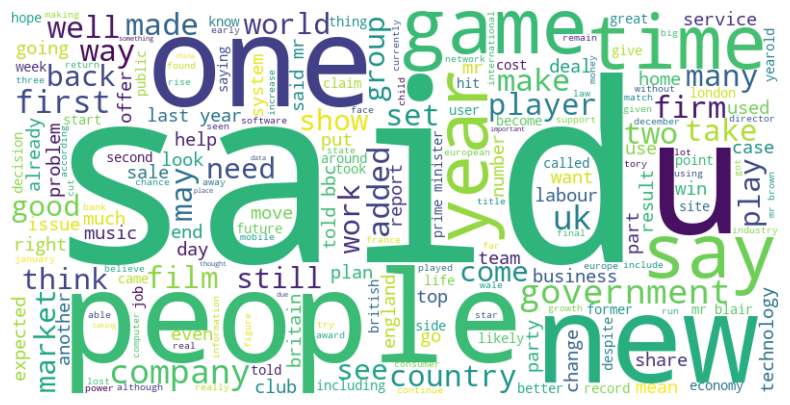

In [ ]:
## Plot word cloud lemmatizado
plot_word_cloud(processed_text_lemmatize)

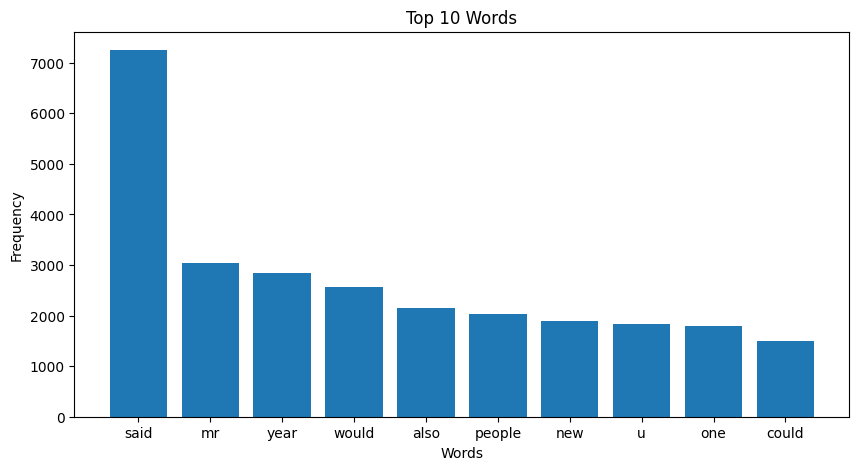

In [104]:
## Plot frequencia lemmatizado
plot_bar_frequencia(processed_text_lemmatize)

### Vetorização

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(processed_texts)

### Data Split

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED,
    stratify=y  # Maintain class distribution
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:\n{pd.Series(y_train).value_counts()}")
print(f"\nClass distribution in test set:\n{pd.Series(y_test).value_counts()}")

Training set size: 1780 samples
Test set size: 445 samples

Class distribution in training set:
sport            409
business         408
politics         333
tech             321
entertainment    309
Name: count, dtype: int64

Class distribution in test set:
business         102
sport            102
politics          84
tech              80
entertainment     77
Name: count, dtype: int64


### Treinamento

In [ ]:
svm_model = SVC(
    kernel='linear',  
    C=1.0,           
    random_state=SEED,
    probability=True
)

print("Training SVM classifier...")
svm_model.fit(X_train, y_train)
print("Training completed!")

Training SVM classifier...
Training completed!


In [100]:
y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)  # Probability scores for each class

print("First 10 predictions vs actual labels:")
for i in range(10):
    print(f"Predicted: {y_pred[i]:15} | Actual: {y_test[i]:15}")

First 10 predictions vs actual labels:
Predicted: business        | Actual: business       
Predicted: business        | Actual: business       
Predicted: entertainment   | Actual: entertainment  
Predicted: business        | Actual: business       
Predicted: business        | Actual: business       
Predicted: sport           | Actual: sport          
Predicted: politics        | Actual: politics       
Predicted: politics        | Actual: politics       
Predicted: sport           | Actual: sport          
Predicted: politics        | Actual: politics       


### Métricas e validações

MODEL PERFORMANCE METRICS
Accuracy:  0.9865 (98.65%)
Precision: 0.9867 (98.67%)
Recall:    0.9865 (98.65%)
F1-Score:  0.9865 (98.65%)

CLASSIFICATION REPORT:
------------------------------------------------------------
               precision    recall  f1-score   support

     business       1.00      0.96      0.98       102
entertainment       0.97      1.00      0.99        77
     politics       0.99      0.98      0.98        84
        sport       0.99      1.00      1.00       102
         tech       0.98      1.00      0.99        80

     accuracy                           0.99       445
    macro avg       0.99      0.99      0.99       445
 weighted avg       0.99      0.99      0.99       445


CONFUSION MATRIX:
------------------------------------------------------------
[[ 98   1   1   1   1]
 [  0  77   0   0   0]
 [  0   1  82   0   1]
 [  0   0   0 102   0]
 [  0   0   0   0  80]]


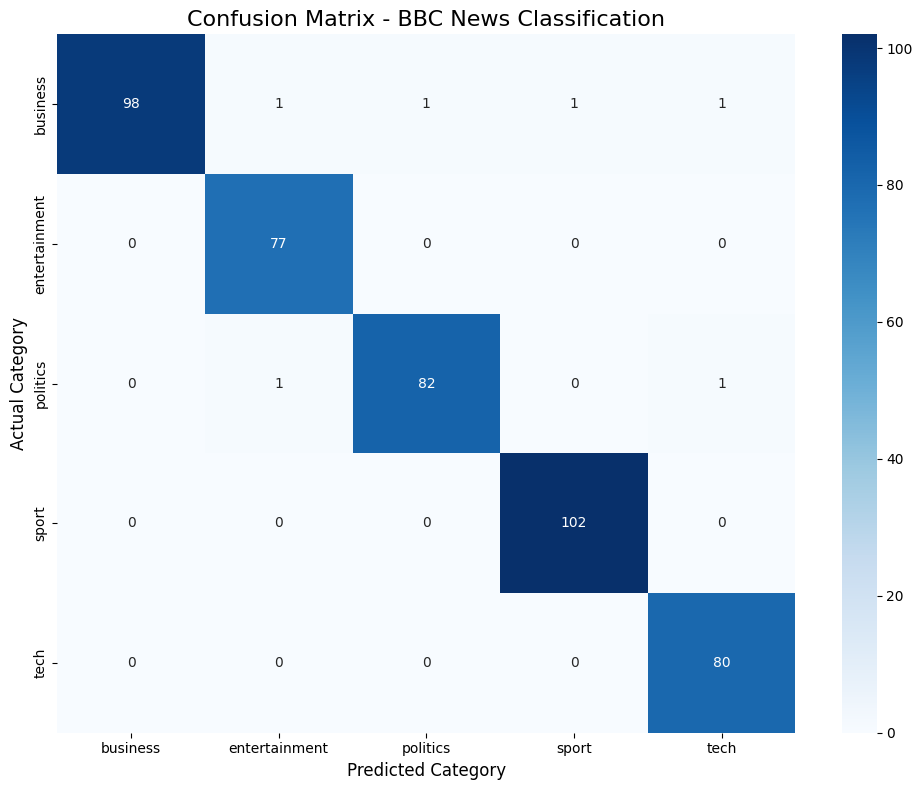


PER-CLASS PERFORMANCE:
------------------------------------------------------------
business        - Precision: 1.0000, Recall: 0.9608, F1: 0.9800
entertainment   - Precision: 0.9747, Recall: 1.0000, F1: 0.9872
politics        - Precision: 0.9880, Recall: 0.9762, F1: 0.9820
sport           - Precision: 0.9903, Recall: 1.0000, F1: 0.9951
tech            - Precision: 0.9756, Recall: 1.0000, F1: 0.9877


In [101]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print("="*60)

# Detailed classification report
print("\nCLASSIFICATION REPORT:")
print("-"*60)
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nCONFUSION MATRIX:")
print("-"*60)
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(set(y)), 
            yticklabels=sorted(set(y)))
plt.title('Confusion Matrix - BBC News Classification', fontsize=16)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class metrics
print("\nPER-CLASS PERFORMANCE:")
print("-"*60)
unique_classes = sorted(set(y))
for class_name in unique_classes:
    class_precision = precision_score(y_test, y_pred, labels=[class_name], average='weighted')
    class_recall = recall_score(y_test, y_pred, labels=[class_name], average='weighted')
    class_f1 = f1_score(y_test, y_pred, labels=[class_name], average='weighted')
    print(f"{class_name:15} - Precision: {class_precision:.4f}, Recall: {class_recall:.4f}, F1: {class_f1:.4f}")

### Validação do modelo

In [ ]:
print("\n" + "="*60)
print("VALIDAÇÃO DO MODELO - RESUMO")
print("="*60)
print(f"✅ Data Split: {X_train.shape[0]} training, {X_test.shape[0]} test samples")
print(f"✅ SVM Classifier: Linear kernel with C={svm_model.C}")
print(f"✅ Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"✅ Overall F1-Score: {f1:.4f} ({f1*100:.2f}%)")
print(f"✅ Number of classes: {len(unique_classes)}")
print(f"✅ Vocabulary size: {X.shape[1]} features")
print(f"✅ Number of documents (total): {len(processed_texts)}")

# Verificação de overfitting
train_accuracy = svm_model.score(X_train, y_train)
test_accuracy = svm_model.score(X_test, y_test)
print(f"\n📊 Training accuracy: {train_accuracy:.4f}")
print(f"📊 Testing accuracy:  {test_accuracy:.4f}")


MODEL VALIDATION SUMMARY
✅ Data Split: 1780 training, 445 test samples
✅ SVM Classifier: Linear kernel with C=1.0
✅ Overall Accuracy: 0.9865 (98.65%)
✅ Overall F1-Score: 0.9865 (98.65%)
✅ Number of classes: 5
✅ Vocabulary size: 5000 features
✅ Number of documents (total): 2225

📊 Training accuracy: 0.9989
📊 Testing accuracy:  0.9865
✅ No significant overfitting detected
